# Audit Data — traffictab23

Six-test analytical audit of `core.observations`. Different purpose than
`spark/jobs/quality_checks.py` (which answers *did the load work correctly*):
this notebook answers *is the data realistic, and what does that mean for
dashboard scope*. See `docs/keterbatasan.md` for the write-up this feeds.

Run locally (not in Docker) against the Postgres port exposed on the host:

```powershell
pip install -r requirements-dev.txt
$env:POSTGRES_HOST="localhost"
$env:POSTGRES_PASSWORD="<from your .env>"
jupyter notebook notebooks/01_audit_data.ipynb
```

In [1]:
import os

from dotenv import load_dotenv
load_dotenv()

os.environ["POSTGRES_HOST"] = "127.0.0.1"
os.environ["POSTGRES_PORT"] = "5433"

import matplotlib.pyplot as plt
import pandas as pd
import psycopg2
from scipy import stats


def get_connection():
    return psycopg2.connect(
        host=os.environ.get("POSTGRES_HOST", "127.0.0.1"),
        port=os.environ.get("POSTGRES_PORT", "5432"),
        user=os.environ.get("POSTGRES_USER", "metropolia"),
        password=os.environ.get("POSTGRES_PASSWORD"),
        dbname=os.environ.get("POSTGRES_DB", "metropolia"),
    )


def query(sql, params=None):
    with get_connection() as conn:
        return pd.read_sql(sql, conn, params=params)


pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

In [2]:
import os
print("cwd:", os.getcwd())
print("POSTGRES_PASSWORD ter-set:", os.environ.get("POSTGRES_PASSWORD") is not None)

cwd: d:\Data science\sem5\ProjectAnbig-MetropoliaCity\notebooks
POSTGRES_PASSWORD ter-set: True


## Test 1 — Temporal consistency

Is `tod_mismatch`/`dow_mismatch` random noise, or systematic (e.g. every
night-time row mislabeled)? A systematic pattern means the raw
`time_of_day`/`day_of_week` columns follow a *different but consistent*
convention (fixable), not just corrupted (unfixable).

C:\Users\Yafi faldin\AppData\Local\Temp\ipykernel_25648\1030941332.py:27: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conn, params=params)


,tod_mismatch_rate,dow_mismatch_rate,total_rows
0,0.7623,0.0000,2102401


C:\Users\Yafi faldin\AppData\Local\Temp\ipykernel_25648\1030941332.py:27: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conn, params=params)


,obs_hour,tod_mismatch_rate,n
0,0,0.9004,87601
1,1,0.8998,87600
2,2,0.8973,87600
3,3,0.8986,87600
4,4,0.8986,87600
5,5,0.7022,87600
6,6,0.7001,87600
7,7,0.7013,87600
8,8,0.6998,87600
9,9,0.7009,87600


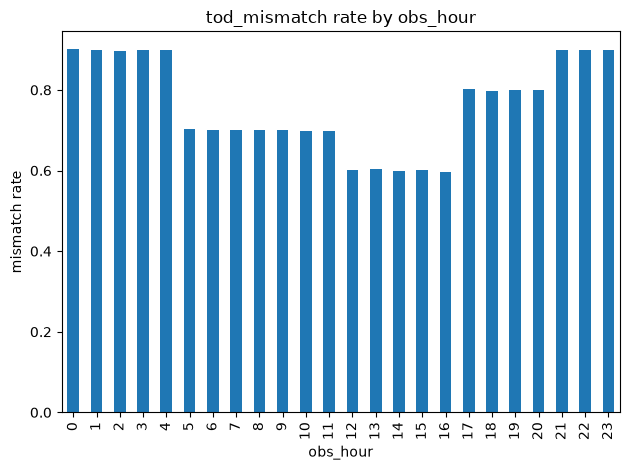

In [3]:
overall = query("""
    select
        avg(tod_mismatch::int) as tod_mismatch_rate,
        avg(dow_mismatch::int) as dow_mismatch_rate,
        count(*) as total_rows
    from core.observations
""")
display(overall)

by_hour = query("""
    select obs_hour, avg(tod_mismatch::int) as tod_mismatch_rate, count(*) as n
    from core.observations
    group by obs_hour
    order by obs_hour
""")
display(by_hour)

by_hour.plot(x="obs_hour", y="tod_mismatch_rate", kind="bar", legend=False,
             title="tod_mismatch rate by obs_hour")
plt.ylabel("mismatch rate")
plt.tight_layout()
plt.show()

**Read this as:** if `tod_mismatch_rate` is ~flat across all `obs_hour` at
some non-trivial rate, that suggests the raw `time_of_day` values were
shuffled/randomized rather than following a shifted-but-consistent
convention (e.g. a different timezone). If it spikes at specific hours,
there may be a fixable pattern (note it here before moving on).

In [4]:
pw = os.environ.get("POSTGRES_PASSWORD")
print(repr(pw))
print(len(pw))

'metropolia123'
13


## Test 2 — Label consistency

`anomaly_label` (0/1) should always agree with `incident_type` (0 = normal,
1-4 = some incident). `label_consistent` already flags this per row
(`spark/jobs/transform.py`); confirm it here and see the breakdown.

In [5]:
consistency = query("""
    select
        count(*) filter (where not label_consistent) as inconsistent_rows,
        count(*) as total_rows
    from core.observations
""")
display(consistency)

breakdown = query("""
    select anomaly_label, incident_type, count(*) as n
    from core.observations
    group by anomaly_label, incident_type
    order by 1, 2
""")
display(breakdown)

C:\Users\Yafi faldin\AppData\Local\Temp\ipykernel_25648\1030941332.py:27: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conn, params=params)


,inconsistent_rows,total_rows
0,0,2102401


C:\Users\Yafi faldin\AppData\Local\Temp\ipykernel_25648\1030941332.py:27: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conn, params=params)


,anomaly_label,incident_type,n
0,0,0,1934193
1,1,1,63013
2,1,2,41975
3,1,3,41971
4,1,4,21249


**Read this as:** `inconsistent_rows` should be 0. If it's not, those rows
need individual inspection before trusting `anomaly_label` as a dashboard
alert signal.

## Test 3 — Spatial stability (summary of prior finding)

Already established in `notebooks/road_gps_stability.py`: GPS spread per
`road_segment_id` averages ~4.16km (100% of 101 segments exceed a 500m
sanity threshold). Loaded here for reference rather than recomputed.

In [6]:
try:
    gps_stability = pd.read_csv("road_gps_stability_output.csv")
    display(gps_stability["radius_p90_m"].describe())
except FileNotFoundError:
    print("Run notebooks/road_gps_stability.py first to generate this file.")

count     101.0000
mean    4,163.7144
std         9.5355
min     4,139.8283
25%     4,158.3373
50%     4,163.8234
75%     4,170.3480
max     4,181.9989
Name: radius_p90_m, dtype: float64

**Conclusion (already acted on):** GPS is not usable as a per-segment
location. `meta.road_positions` uses `source = illustrative_grid` instead
(see `notebooks/populate_road_positions.py`, `docs/keterbatasan.md`).

## Test 4 — Distributional realism

Columns suspected synthetic (flat/uniform distributions): `jam_density_index`,
`lane_occupancy_rate`, `v2x_packet_loss_rate`, `v2v_beacon_interval_avg`,
`v2x_message_delay_avg`, `gps_latitude`, `gps_longitude`. Sampled (not full
2.1M rows) for speed; sample size is large enough for the KS test to be
meaningful.

C:\Users\Yafi faldin\AppData\Local\Temp\ipykernel_25648\1030941332.py:27: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conn, params=params)


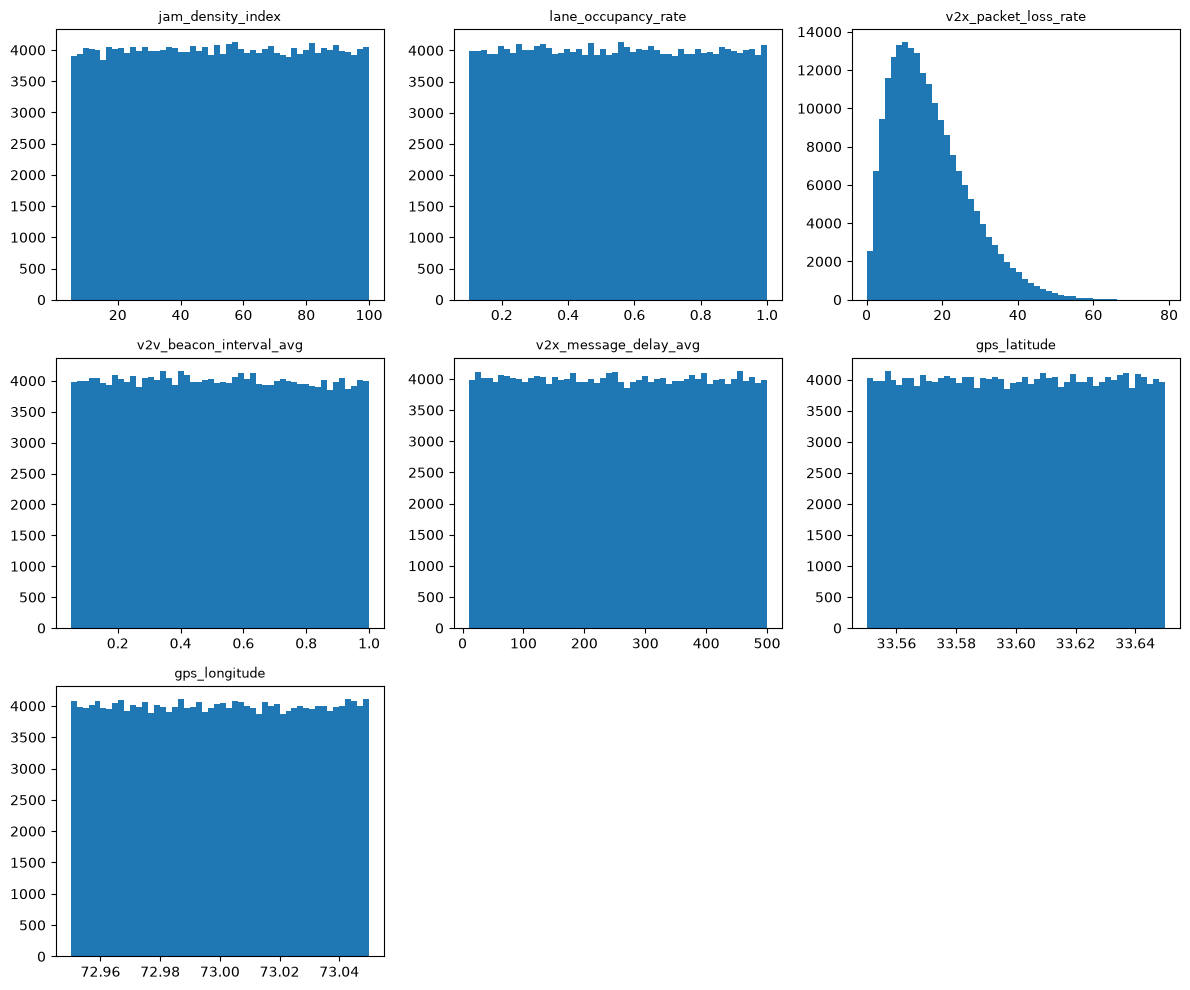

,column,ks_stat,p_value,min,max
0,jam_density_index,0.0014,0.8216,5.0004,99.9991
1,lane_occupancy_rate,0.0015,0.7380,0.1000,1.0000
2,v2x_packet_loss_rate,0.5068,0.0000,0.0258,78.9382
3,v2v_beacon_interval_avg,0.0040,0.0031,0.0500,1.0000
4,v2x_message_delay_avg,0.0020,0.4015,10.0004,499.9986
5,gps_latitude,0.0011,0.9745,33.5500,33.6500
6,gps_longitude,0.0018,0.5559,72.9500,73.0500


In [7]:
SUSPECT_COLUMNS = [
    "jam_density_index",
    "lane_occupancy_rate",
    "v2x_packet_loss_rate",
    "v2v_beacon_interval_avg",
    "v2x_message_delay_avg",
    "gps_latitude",
    "gps_longitude",
]

sample = query(f"""
    select {', '.join(SUSPECT_COLUMNS)}
    from core.observations
    order by random()
    limit 200000
""")

fig, axes = plt.subplots(3, 3, figsize=(12, 10))
for ax, col in zip(axes.flat, SUSPECT_COLUMNS):
    ax.hist(sample[col].dropna(), bins=50)
    ax.set_title(col, fontsize=9)
for ax in axes.flat[len(SUSPECT_COLUMNS):]:
    ax.axis("off")
plt.tight_layout()
plt.show()

ks_results = []
for col in SUSPECT_COLUMNS:
    vals = sample[col].dropna()
    lo, hi = vals.min(), vals.max()
    stat, pvalue = stats.kstest(vals, "uniform", args=(lo, hi - lo))
    ks_results.append({"column": col, "ks_stat": stat, "p_value": pvalue,
                        "min": lo, "max": hi})
ks_df = pd.DataFrame(ks_results)
display(ks_df)

**Read this as:** a low `ks_stat` (close to 0) and high `p_value` mean the
column doesn't reject the null hypothesis of being uniformly distributed —
i.e. it looks synthetic/randomly generated rather than a real physical
measurement. A high `ks_stat` / low `p_value` means it's *not* uniform,
which is more consistent with real sensor data. Flag which columns fail
here in `docs/keterbatasan.md`.

## Test 5 — Range plausibility

Deeper than `RANGE_CHECKS` in `spark/jobs/quality_checks.py` (which only
counts out-of-range rows): here we look at the actual percentile spread,
to decide realistic bounds for `config/thresholds.yaml`.

Bounds mirrored from `spark/common/schema.py` — keep in sync manually if
that file changes.

In [8]:
RANGE_CHECKS = {
    "gps_latitude": (33.0, 34.0),
    "gps_longitude": (72.5, 73.5),
    "vehicle_count": (0, 100),
    "average_speed": (0, 200),
    "lane_occupancy_rate": (0.0, 1.0),
    "v2x_packet_loss_rate": (0.0, 100.0),
    "anomaly_label": (0, 1),
    "incident_type": (0, 4),
}

rows = []
for col, (lo, hi) in RANGE_CHECKS.items():
    r = query(f"""
        select
            count(*) filter (where {col} < %(lo)s or {col} > %(hi)s)::float
                / count(*) as pct_out_of_range,
            percentile_cont(0.01) within group (order by {col}) as p1,
            percentile_cont(0.50) within group (order by {col}) as p50,
            percentile_cont(0.99) within group (order by {col}) as p99
        from core.observations
    """, params={"lo": lo, "hi": hi})
    r.insert(0, "column", col)
    rows.append(r)

range_summary = pd.concat(rows, ignore_index=True)
display(range_summary)

C:\Users\Yafi faldin\AppData\Local\Temp\ipykernel_25648\1030941332.py:27: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conn, params=params)


,column,pct_out_of_range,p1,p50,p99
0,gps_latitude,0.0000,33.5510,33.6000,33.6490
1,gps_longitude,0.0000,72.9510,73.0000,73.0490
2,vehicle_count,0.0000,7.0000,15.0000,25.0000
3,average_speed,0.0000,13.4605,59.9968,106.5349
4,lane_occupancy_rate,0.0000,0.1091,0.5499,0.9911
5,v2x_packet_loss_rate,0.0000,1.4082,14.7948,46.9953
6,anomaly_label,0.0000,0.0000,0.0000,1.0000
7,incident_type,0.0000,0.0000,0.0000,4.0000


In [10]:
delay_percentiles = query("""
    select
        percentile_cont(0.01) within group (order by v2x_message_delay_avg) as p1,
        percentile_cont(0.50) within group (order by v2x_message_delay_avg) as p50,
        percentile_cont(0.90) within group (order by v2x_message_delay_avg) as p90,
        percentile_cont(0.99) within group (order by v2x_message_delay_avg) as p99
    from core.observations
""")
display(delay_percentiles)

packet_loss_p90 = query("""
    select percentile_cont(0.90) within group (order by v2x_packet_loss_rate) as p90
    from core.observations
""")
display(packet_loss_p90)

C:\Users\Yafi faldin\AppData\Local\Temp\ipykernel_25648\1030941332.py:27: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conn, params=params)


,p1,p50,p90,p99
0,14.8843,255.1328,451.0062,495.0489


C:\Users\Yafi faldin\AppData\Local\Temp\ipykernel_25648\1030941332.py:27: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conn, params=params)


,p90
0,31.0163


**Read this as:** use `p1`/`p99` here (not guessed numbers) to fill in
`config/thresholds.yaml`'s `v2x_status` bounds. A non-trivial
`pct_out_of_range` on a column not yet in `thresholds.yaml` may mean it
needs a bound added there too.

## Test 6 — Signal correlation

Does `anomaly_label` carry a real physical signal (anomalous rows *look*
different in traffic metrics), or is it essentially a random label pasted
onto otherwise-normal rows? This determines whether an anomaly-detection
dashboard feature built on this label is meaningful.

In [9]:
by_label = query("""
    select
        anomaly_label,
        avg(vehicle_count) as avg_vehicle_count,
        avg(average_speed) as avg_speed,
        avg(hard_braking_events) as avg_hard_braking,
        avg(rapid_acceleration_events) as avg_rapid_accel,
        avg(lane_occupancy_rate) as avg_lane_occupancy,
        count(*) as n
    from core.observations
    group by anomaly_label
""")
display(by_label)

corr_sample = query("""
    select anomaly_label, vehicle_count, average_speed,
           hard_braking_events, rapid_acceleration_events, lane_occupancy_rate
    from core.observations
    order by random()
    limit 200000
""")
display(corr_sample.corr()[["anomaly_label"]].sort_values("anomaly_label", ascending=False))

C:\Users\Yafi faldin\AppData\Local\Temp\ipykernel_25648\1030941332.py:27: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conn, params=params)


,anomaly_label,avg_vehicle_count,avg_speed,avg_hard_braking,avg_rapid_accel,avg_lane_occupancy,n
0,0,14.9988,59.9962,0.2496,0.3493,0.5500,1934193
1,1,15.0050,60.0049,0.2519,0.3509,0.5493,168208


C:\Users\Yafi faldin\AppData\Local\Temp\ipykernel_25648\1030941332.py:27: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conn, params=params)


,anomaly_label
anomaly_label,1.0000
rapid_acceleration_events,0.0025
average_speed,0.0015
lane_occupancy_rate,0.0004
vehicle_count,0.0003
hard_braking_events,-0.0005


**Read this as:** if the `avg_*` values barely differ between
`anomaly_label` 0 and 1, and correlations are all near 0, the anomaly
label is not backed by a physically-plausible signal in this dataset —
an "anomaly detected" dashboard feature would just be surfacing the raw
label, not something derived/validated from the traffic metrics
themselves. Note the conclusion here.

## Summary — fill in after running

| Test | Verdict | Dashboard implication |
|---|---|---|
| 1. Temporal consistency | dow selalu cocok; tod mismatch sistematis (bukan acak per baris, tapi implied fixed-rate 10/30/40/20%) | Jangan percaya time_of_day mentah sama sekali; pakai weekday_from_ts/obs_hour |
| 2. Label consistency | 100% konsisten, anomaly_rate 8.0% | Aman dipakai sebagai filter incident_type |
| 3. Spatial stability | Tidak usable (sudah ditangani) | Map pakai illustrative grid, ditandai jelas |
| 4. Distributional realism | 6/7 kolom curiga = uniform/sintetis; v2x_packet_loss_rate terkecuali | Hindari fitur yang mengasumsikan realisme statistik kolom sintetis |
| 5. Range plausibility | 0% out-of-range di semua kolom; persentil terisi | thresholds.yaml terisi dari p50/p90 |
| 6. Signal correlation | Tidak ada korelasi (~0) antara anomaly_label & metrik lalu lintas | Dashboard: sajikan sebagai "catatan insiden", bukan "deteksi anomali" |

Carry the filled-in verdicts into `docs/keterbatasan.md`.